In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv('wine_data.csv',usecols=[0,1,2])
df.columns = ['C_label','alcohol','malic_acid']

In [4]:
df.head(5)

,C_label,alcohol,malic_acid
0,1,13.20,1.78
1,1,13.16,2.36
2,1,14.37,1.95
3,1,13.24,2.59
4,1,14.20,1.76


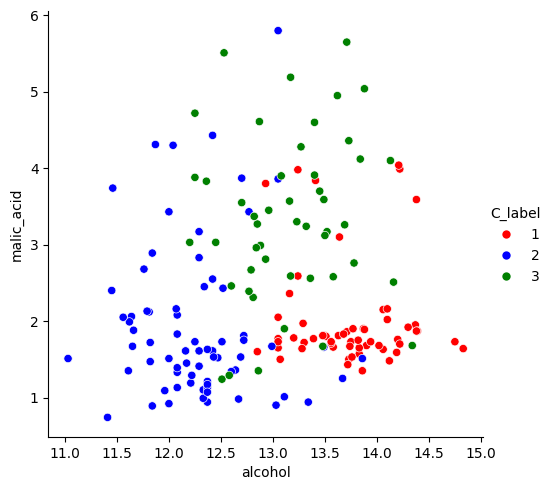

In [5]:
colors = {1: 'red', 2: 'blue', 3: 'green'}
sns.relplot(x='alcohol',y='malic_acid',data=df,kind='scatter',hue='C_label',palette=colors)

In [6]:
from sklearn.model_selection import train_test_split
X = df.drop('C_label',axis=1)
y = df['C_label'] 
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [7]:
X_train.shape,X_test.shape

((141, 2), (36, 2))

In [8]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
X_train_scaled = pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [10]:
np.round(X_train.describe(),2)

,alcohol,malic_acid
count,141.00,141.00
mean,12.97,2.33
std,0.79,1.15
min,11.41,0.74
25%,12.33,1.60
50%,12.99,1.81
75%,13.63,3.03
max,14.83,5.80


In [11]:
np.round(X_train_scaled.describe(),2)

,alcohol,malic_acid
count,141.00,141.00
mean,0.46,0.31
std,0.23,0.23
min,0.00,0.00
25%,0.27,0.17
50%,0.46,0.21
75%,0.65,0.45
max,1.00,1.00


Text(0.5, 1.0, 'After Scaling')

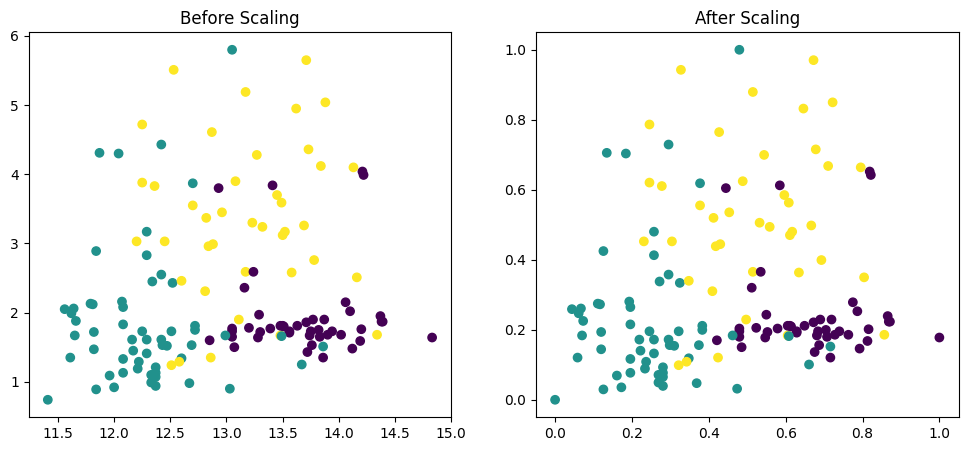

In [12]:
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(12,5))
ax1.scatter(x='alcohol',y='malic_acid',c=y_train,data=X_train)
ax1.set_title('Before Scaling') 
ax2.scatter(x='alcohol',y='malic_acid',c=y_train,data=X_train_scaled)
ax2.set_title('After Scaling')

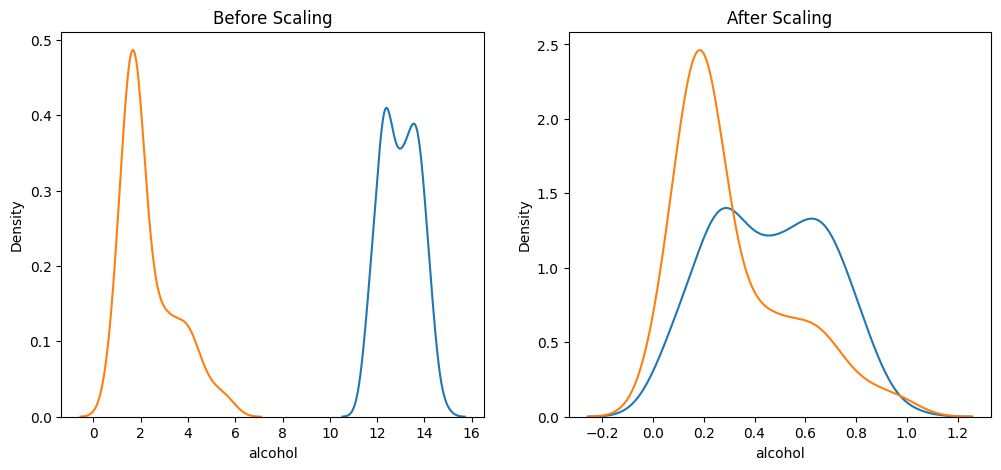

In [15]:
fig , (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

ax1.set_title('Before Scaling')
sns.kdeplot(X_train['alcohol'],ax = ax1)
sns.kdeplot(X_train['malic_acid'],ax = ax1)


ax2.set_title('After Scaling')
sns.kdeplot(X_train_scaled['alcohol'],ax = ax2)
sns.kdeplot(X_train_scaled['malic_acid'],ax = ax2)

plt.show()


<Axes: title={'center': 'Alcohol Distribution after Scaling'}, xlabel='alcohol', ylabel='Density'>

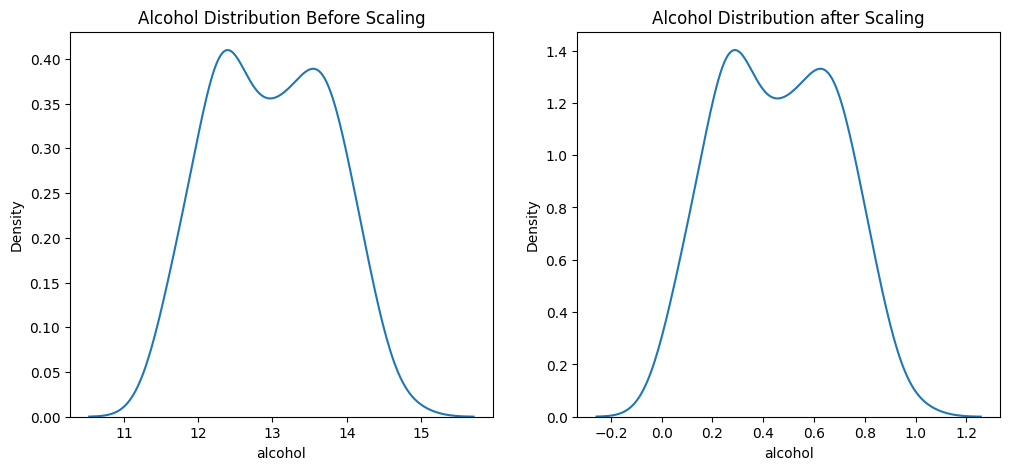

In [17]:
fig, (ax1,ax2) = plt.subplots(ncols=2,figsize=(12,5))

ax1.set_title('Alcohol Distribution Before Scaling')
sns.kdeplot(X_train['alcohol'],ax=ax1)


ax2.set_title('Alcohol Distribution after Scaling')
sns.kdeplot(X_train_scaled['alcohol'],ax=ax2)